### 📊 Classwork 1: The Regional Economic Profile (Medium)
Goal: Compare the three main economic sectors across the world's regions using a stacked bar chart.

English Task: 1. Group the data by Region and calculate the average for Agriculture, Industry, and Service.
2. Create a Stacked Bar Chart where each bar represents a region, and the colors show the sector breakdown.
3. Add a legend, a title, and rotate the x-axis labels so they are readable.

Հայերեն Առաջադրանք:

Խմբավորեք տվյալները ըստ Region-ի և հաշվեք Agriculture, Industry և Service ոլորտների միջինը:

Ստեղծեք կուտակային սյունակային գրաֆիկ (Stacked Bar Chart), որտեղ յուրաքանչյուր սյունակ ներկայացնում է տարածաշրջանը, իսկ գույները՝ ոլորտների բաշխվածությունը:

Ավելացրեք լեգենդ, վերնագիր և պտտեք x-առանցքի պիտակները, որպեսզի դրանք ընթեռնելի լինեն:

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ssl 

ssl._create_default_https_context = ssl._create_unverified_context

# Load the data
url = "https://raw.githubusercontent.com/bnokoro/Data-Science/master/countries%20of%20the%20world.csv"
df = pd.read_csv(url)

# Clean decimal commas and whitespace
cols = ['Agriculture', 'Industry', 'Service', 'Literacy (%)', 'GDP ($ per capita)', 'Pop. Density (per sq. mi.)']
for col in cols:
    df[col] = df[col].astype(str).str.replace(',', '.').astype(float)
df['Region'] = df['Region'].str.strip()
df['Country'] = df['Country'].str.strip()

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the data
url = "https://raw.githubusercontent.com/bnokoro/Data-Science/master/countries%20of%20the%20world.csv"
df = pd.read_csv(url)

# 2. Identify the economic columns
econ_cols = ['Agriculture', 'Industry', 'Service']

# 3. The "Cleaning Pipeline"
for col in econ_cols:
    # Convert to string -> Replace comma with dot -> Convert to float -> Fill missing with 0
    df[col] = df[col].astype(str).str.replace(',', '.').astype(float).fillna(0)

# 4. Clean the Region column (it has trailing spaces like "ASIA   ")
df['Region'] = df['Region'].str.strip()

# 5. NOW run the Classwork 1 logic
economic_profile = df.groupby('Region')[econ_cols].mean()

# Verify it worked
print(economic_profile.head())

                      Agriculture  Industry   Service
Region                                               
ASIA (EX. NEAR EAST)     0.177643  0.302143  0.520107
BALTICS                  0.045000  0.293333  0.661667
C.W. OF IND. STATES      0.192000  0.328000  0.480167
EASTERN EUROPE           0.092167  0.309250  0.598667
LATIN AMER. & CARIB      0.086978  0.244733  0.621800


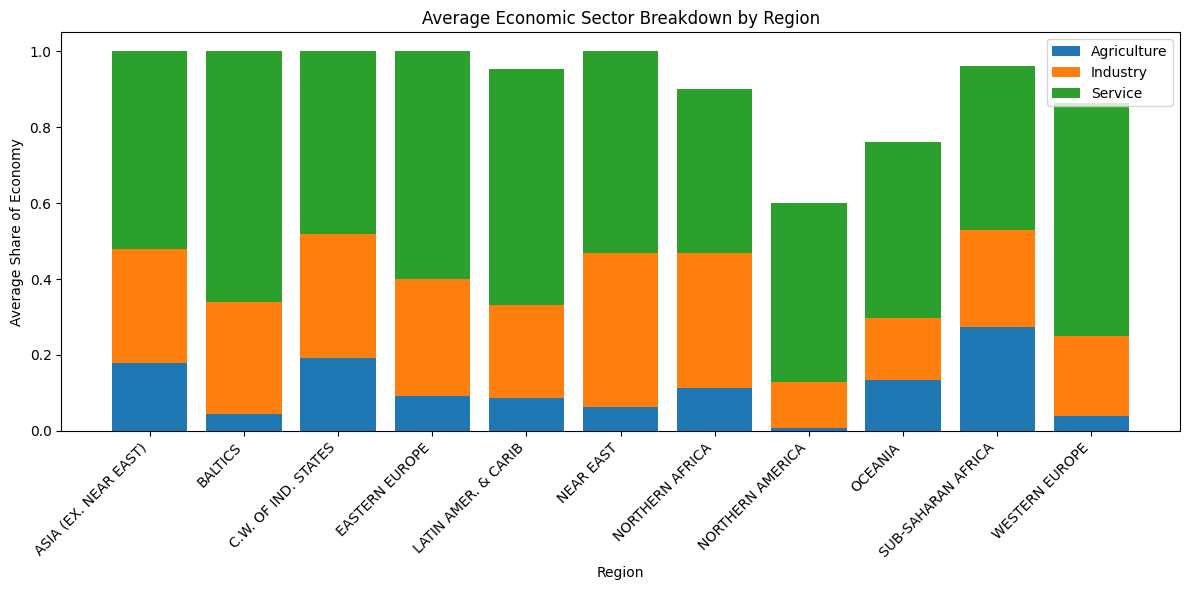

In [21]:
df_1 = df.groupby('Region')[['Agriculture', 'Industry', 'Service']].agg('mean')

plt.figure(figsize=(12,6))

plt.bar(
    df_1.index,
    df_1['Agriculture'],
    label='Agriculture'
)

plt.bar(
    df_1.index,
    df_1['Industry'],
    bottom=df_1['Agriculture'],
    label='Industry'
)

# Third layer (stacked on top of both)
plt.bar(
    df_1.index,
    df_1['Service'],
    bottom=df_1['Agriculture'] + df_1['Industry'],
    label='Service'
)

plt.title('Average Economic Sector Breakdown by Region')
plt.xlabel('Region')
plt.ylabel('Average Share of Economy')

plt.xticks(rotation=45, ha='right')
plt.legend()

plt.tight_layout()
plt.show()

In [22]:
economic_profile

,Agriculture,Industry,Service
Region,,,
ASIA (EX. NEAR EAST),0.177643,0.302143,0.520107
BALTICS,0.045000,0.293333,0.661667
C.W. OF IND. STATES,0.192000,0.328000,0.480167
EASTERN EUROPE,0.092167,0.309250,0.598667
LATIN AMER. & CARIB,0.086978,0.244733,0.621800
NEAR EAST,0.063812,0.406000,0.530000
NORTHERN AFRICA,0.112500,0.355167,0.432000
NORTHERN AMERICA,0.008400,0.119600,0.472200
OCEANIA,0.133429,0.164000,0.463952


In [24]:
?plt.legend

Signature: plt.legend(*args, **kwargs) -> 'Legend'
Docstring:
Place a legend on the Axes.

Call signatures::

    legend()
    legend(handles, labels)
    legend(handles=handles)
    legend(labels)

The call signatures correspond to the following different ways to use
this method:

**1. Automatic detection of elements to be shown in the legend**

The elements to be added to the legend are automatically determined,
when you do not pass in any extra arguments.

In this case, the labels are taken from the artist. You can specify
them either at artist creation or by calling the
:meth:`~.Artist.set_label` method on the artist::

    ax.plot([1, 2, 3], label='Inline label')
    ax.legend()

or::

    line, = ax.plot([1, 2, 3])
    line.set_label('Label via method')
    ax.legend()

.. note::
    Specific artists can be excluded from the automatic legend element
    selection by using a label starting with an underscore, "_".
    A string starting with an underscore is the default label for a

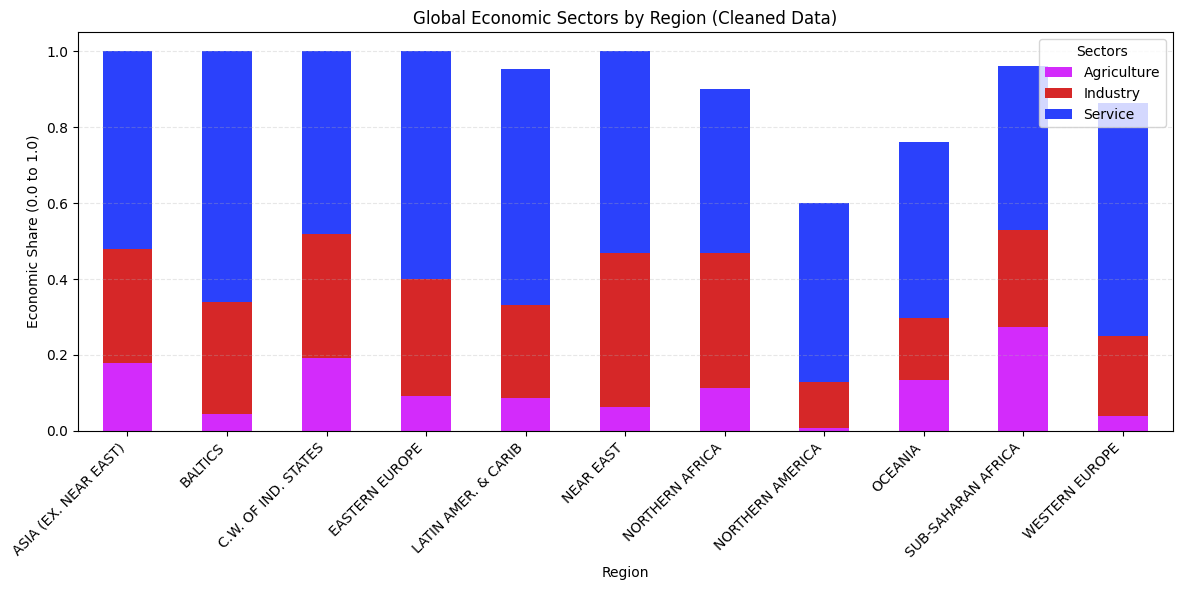

In [25]:
# Create the Stacked Bar Chart
economic_profile.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#d32bfb', '#d62728', '#2b41fb'])


plt.title('Global Economic Sectors by Region (Cleaned Data)')
plt.ylabel('Economic Share (0.0 to 1.0)')
plt.xlabel('Region')
plt.legend(title='Sectors',  loc = 'upper right')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### 🚀 Classwork 2: The Scale of Nations 
Goal: Analyze global outliers by combining log-scaling, subplotting, and manual data-point annotation.

English Task:

Create a figure with two subplots (1 row, 2 columns).

Subplot A: Plot Area (sq. mi.) vs Population. Both axes must use a log scale. Color the points by GDP ($ per capita).

Subplot B: Plot a Histogram of Pop. Density. Use 50 bins and a log scale for the x-axis to reveal the "hidden" distribution of tiny, dense nations.

The Challenge: In Subplot A, find the country with the absolute highest Pop. Density (hint: it's Monaco or Macau) and use plt.annotate to label it with an arrow.

Հայերեն Առաջադրանք:

Ստեղծեք գրաֆիկ՝ բաղկացած երկու subplot-ից (1 տող, 2 սյունակ):

Subplot A: Գծեք Area (sq. mi.)-ն ընդդեմ Population-ի: Երկու առանցքներն էլ պետք է լինեն լոգարիթմական սանդղակով: Գունավորեք կետերը ըստ GDP ($ per capita)-ի:

Subplot B: Գծեք Pop. Density-ի հիստոգրամը: Օգտագործեք 50 սեգմենտ (bins) և լոգարիթմական սանդղակ x-առանցքի համար՝ փոքր, խիտ բնակեցված երկրների բաշխվածությունը տեսնելու համար:

Մարտահրավեր: Subplot A-ում գտեք ամենաբարձր Pop. Density ունեցող երկիրը և օգտագործեք plt.annotate՝ այն սլաքով պիտակավորելու համար:

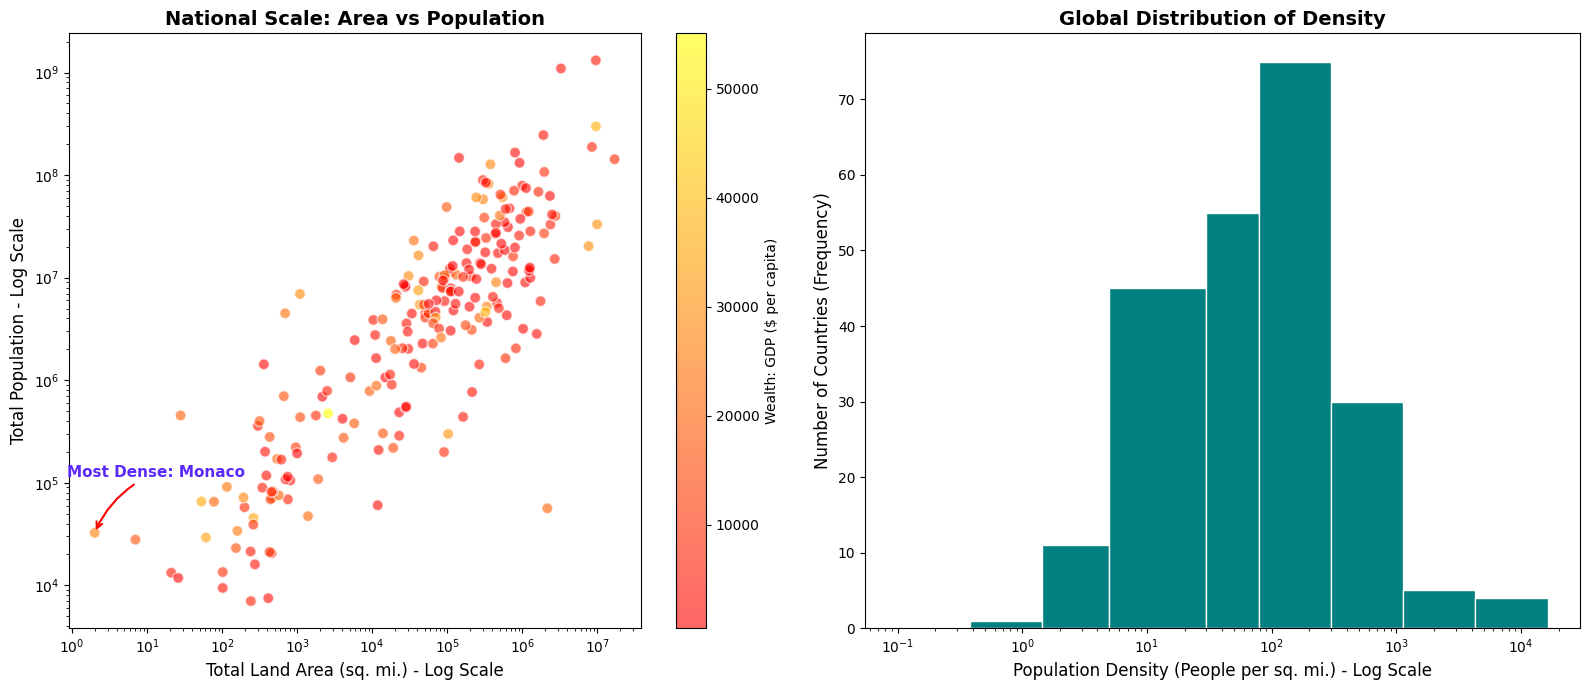

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Convert strings with commas to floats
cols = ['Area (sq. mi.)', 'Population', 'Pop. Density (per sq. mi.)', 'GDP ($ per capita)']
for col in cols:
    df[col] = df[col].astype(str).str.replace(',', '.').astype(float)

df['Country'] = df['Country'].str.strip()
df['Region'] = df['Region'].str.strip()

# 2. CREATE THE VISUALIZATION
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- SUBPLOT A: Area vs Population ---
scatter = ax1.scatter(df['Area (sq. mi.)'], df['Population'], 
                     c=df['GDP ($ per capita)'], cmap='autumn', alpha=0.6, edgecolors='w', s=60)

ax1.set_xscale('log')
ax1.set_yscale('log')

# Axis Labels
ax1.set_xlabel('Total Land Area (sq. mi.) - Log Scale', fontsize=12)
ax1.set_ylabel('Total Population - Log Scale', fontsize=12)
ax1.set_title('National Scale: Area vs Population', fontsize=14, fontweight='bold')

# Colorbar for Subplot A
cbar = plt.colorbar(scatter, ax=ax1)
cbar.set_label('Wealth: GDP ($ per capita)', fontsize=10)

# --- THE ANNOTATION (Finding the Outlier) ---
# We find the country with the highest density
top_dense_row = df.loc[df['Pop. Density (per sq. mi.)'].idxmax()]
target_name = top_dense_row['Country']
target_x = top_dense_row['Area (sq. mi.)']
target_y = top_dense_row['Population']

ax1.annotate(f"Most Dense: {target_name}", 
             xy=(target_x, target_y),           # The data point
             xytext=(-20, 40),                   # Distance in 'points' from the point
             textcoords='offset points',        # Crucial for log scales!
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=.2', color='red', lw=1.5),
             fontsize=11, fontweight='bold', color='#5b2bfb')


# --- SUBPLOT B: Population Density Distribution ---
# Using logspace for bins ensures bars look correct on a log axis
bins = np.logspace(np.log10(df['Pop. Density (per sq. mi.)'].min() + 0.1), 
                   np.log10(df['Pop. Density (per sq. mi.)'].max()), 10)

bins[3] = 5
bins[4] = 30
# print(bins)
ax2.hist(df['Pop. Density (per sq. mi.)'].dropna(), bins= bins , color='teal', edgecolor='white')

ax2.set_xscale('log')
ax2.set_xlabel('Population Density (People per sq. mi.) - Log Scale', fontsize=12)
ax2.set_ylabel('Number of Countries (Frequency)', fontsize=12)
ax2.set_title('Global Distribution of Density', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

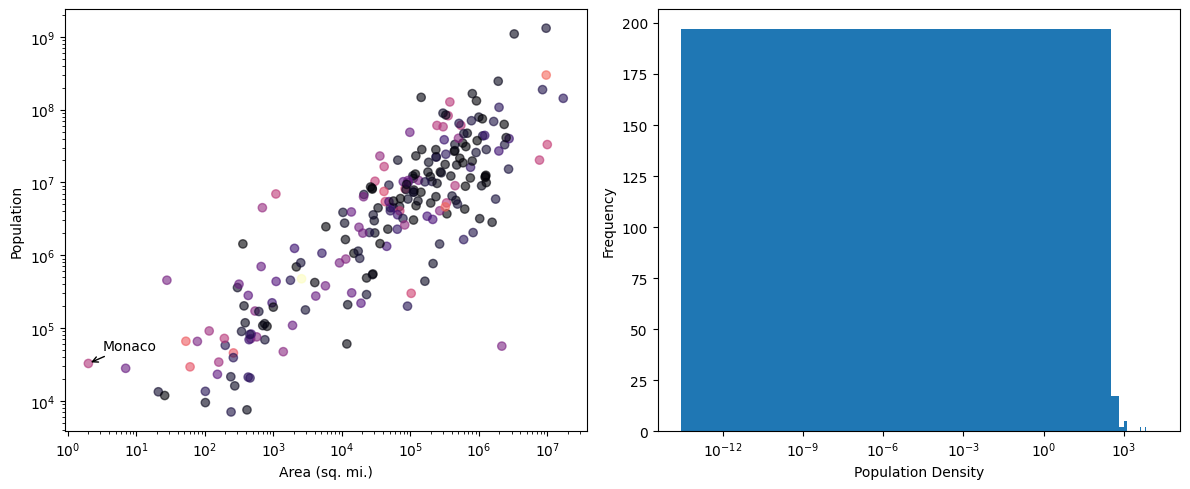

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(df['Area (sq. mi.)'], df['Population'], c=df['GDP ($ per capita)'], cmap='magma', alpha=0.6)
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlabel('Area (sq. mi.)')
ax[0].set_ylabel('Population')


ax[1].hist(df['Pop. Density (per sq. mi.)'], bins=50)
ax[1].set_xscale('log')
ax[1].set_xlabel('Population Density')
ax[1].set_ylabel('Frequency')


max_density = df.loc[df['Pop. Density (per sq. mi.)'].idxmax()]

ax[0].annotate(
    max_density['Country'],
    xy=(max_density['Area (sq. mi.)'], max_density['Population']),
    xytext=(10, 10),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->')
)

plt.tight_layout()
plt.show()

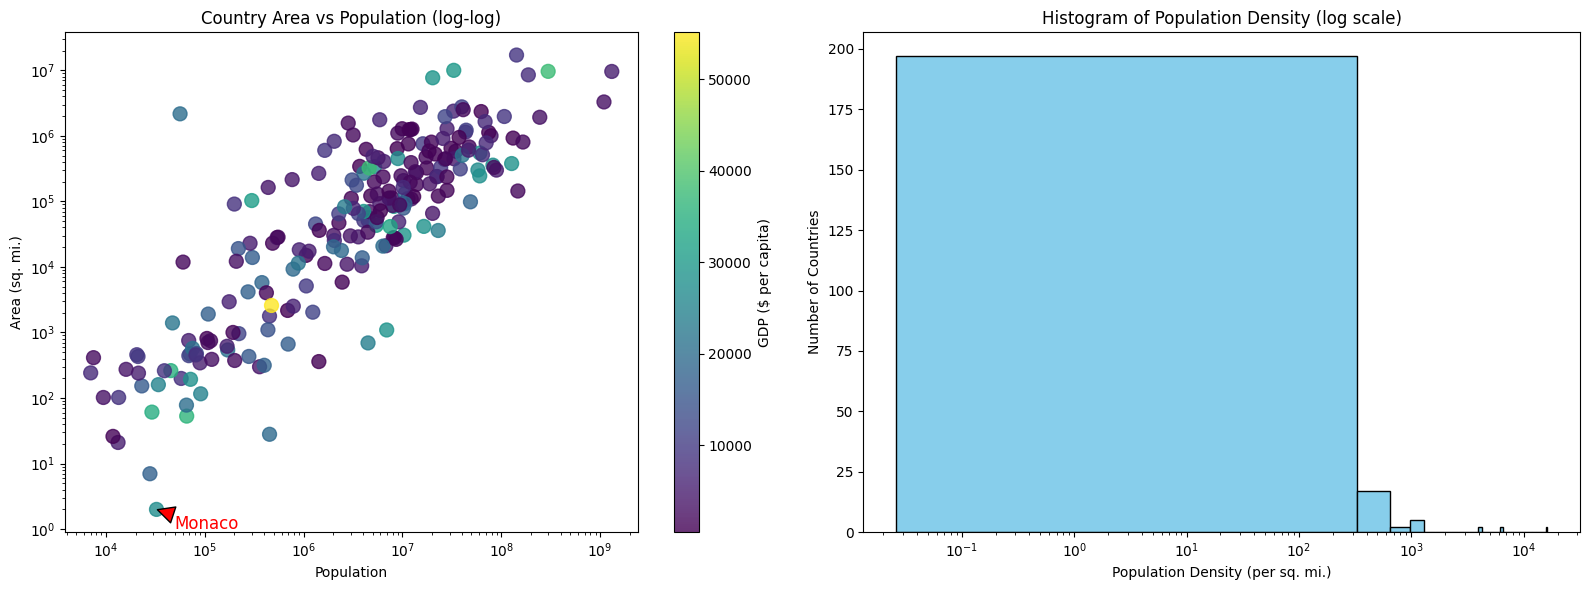

In [39]:
df["Pop. Density"] = df["Population"] / df["Area (sq. mi.)"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter = axes[0].scatter(
    df["Population"],
    df["Area (sq. mi.)"],
    c=df["GDP ($ per capita)"],
    cmap="viridis",
    s=100,
    alpha=0.8
)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Population")
axes[0].set_ylabel("Area (sq. mi.)")
axes[0].set_title("Country Area vs Population (log-log)")

cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label("GDP ($ per capita)")

max_density_idx = df["Pop. Density"].idxmax()
max_country = df.loc[max_density_idx, "Country"]
x = df.loc[max_density_idx, "Population"]
y = df.loc[max_density_idx, "Area (sq. mi.)"]
axes[0].annotate(
    max_country,
    xy=(x, y),
    xytext=(x*1.5, y*0.5),
    arrowprops=dict(facecolor='red', shrink=0.05),
    fontsize=12,
    color='red'
)

axes[1].hist(df["Pop. Density"], bins=50, color='skyblue', edgecolor='black')
axes[1].set_xscale("log")
axes[1].set_xlabel("Population Density (per sq. mi.)")
axes[1].set_ylabel("Number of Countries")
axes[1].set_title("Histogram of Population Density (log scale)")

plt.tight_layout()
plt.show()

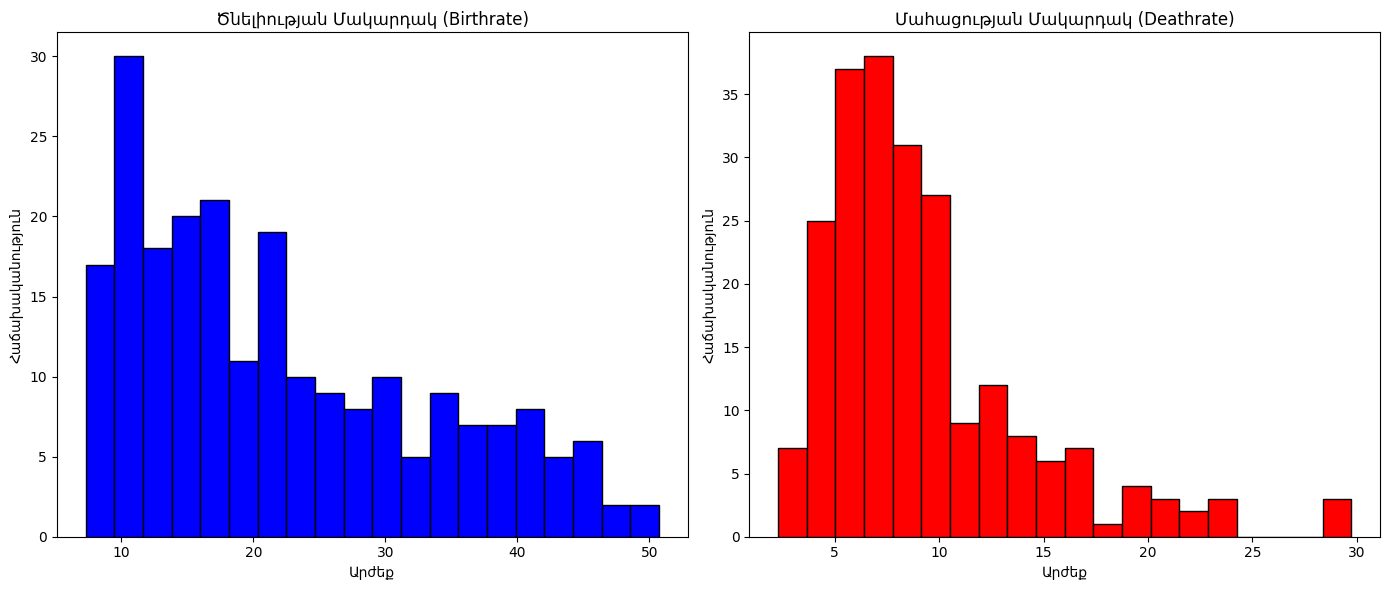

In [40]:
for col in ['Birthrate', 'Deathrate']:
    df[col] = df[col].astype(str).str.replace(',', '.').astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].hist(df['Birthrate'].dropna(), bins=20, color='blue', edgecolor='black')
axes[0].set_title('Ծնելիության Մակարդակ (Birthrate)')
axes[0].set_xlabel('Արժեք')
axes[0].set_ylabel('Հաճախականություն')

axes[1].hist(df['Deathrate'].dropna(), bins=20, color='red', edgecolor='black')
axes[1].set_title('Մահացության Մակարդակ (Deathrate)')
axes[1].set_xlabel('Արժեք')
axes[1].set_ylabel('Հաճախականություն')



plt.tight_layout()
plt.show()